# Chapter 15 Processing Sequences Using RNNs and CNNs

## 15.3 Forecasting a Time Series

In [1]:
import numpy as np

np.random.rand(4, 3, 2)

array([[[0.55939901, 0.35334448],
        [0.05164734, 0.65767125],
        [0.62272672, 0.55714563]],

       [[0.76834404, 0.92334816],
        [0.06121068, 0.53954316],
        [0.81764221, 0.05967699]],

       [[0.76776156, 0.84578247],
        [0.32453583, 0.03770741],
        [0.82743738, 0.53612376]],

       [[0.73756214, 0.96733389],
        [0.98066203, 0.03025871],
        [0.48165411, 0.77870812]]])

In [2]:
np.array([1, 2, 3]) - np.array([[1, 2, 3]]).T

array([[ 0,  1,  2],
       [-1,  0,  1],
       [-2, -1,  0]])

In [3]:
np.array([1, 2, 3])[:, np.newaxis]

array([[1],
       [2],
       [3]])

In [4]:
a = np.arange(6).reshape(2, 3)
print(a[:, np.newaxis])
print(a[:, None])
print(a[:, :, np.newaxis])

[[[0 1 2]]

 [[3 4 5]]]
[[[0 1 2]]

 [[3 4 5]]]
[[[0]
  [1]
  [2]]

 [[3]
  [4]
  [5]]]


In [5]:
def generate_time_series(batch_size: int, n_steps: int) -> np.ndarray:
    freq1, freq2, phase1, phase2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = (
        0.5 * np.sin((10 * freq1 + 10) * (time - phase1))
        + 0.2 * np.sin(20 * freq2 + 20) * (time - phase2)
        + 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)
    )
    return series[..., np.newaxis]


generate_time_series(2, 3)

array([[[-0.35006542],
        [ 0.28052944],
        [ 0.30967175]],

       [[-0.47863247],
        [-0.06294938],
        [ 0.4325777 ]]])

In [6]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

n_instances = 10_000
n_steps = 50
dataset = generate_time_series(n_instances, n_steps + 1)
split = [7_000, 9_000]
X_train, y_train = dataset[: split[0], :-1], dataset[: split[0], -1]
X_valid, y_valid = dataset[split[0] : split[1], :-1], dataset[split[0] : split[1], -1]
X_test, y_test = dataset[split[1] :, -1], dataset[split[1] :, -1]

print(X_valid.shape)
print(y_valid.shape)

(2000, 50, 1)
(2000, 1)


In [49]:
np.save("dataset", dataset)

### 15.3.1 Baseline Metrics

##### Naive forcasting

In [7]:
y_pred = X_valid[:, -1]
y_pred.shape

(2000, 1)

In [8]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_pred, y_valid)

0.013142678452406407

##### Linear Regression

In [9]:
import tensorflow as tf

model_lin = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(X_train[0].shape)),
        tf.keras.layers.Dense(1),
    ]
)

model_lin.compile(optimizer="adam", loss="mse", metrics="mae")
model_lin.summary()

2023-01-31 06:09:19.513279: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 50)                0         
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 51
Trainable params: 51
Non-trainable params: 0
_________________________________________________________________


2023-01-31 06:09:21.855101: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-31 06:09:21.917672: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-31 06:09:21.918092: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-31 06:09:21.918995: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

In [10]:
import time
from pathlib import Path

root_logdir = Path().absolute() / "logs"
run_logdir = root_logdir / time.strftime("run_%Y_%m_%d-%H_%M_%S")

%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

Launching TensorBoard...

In [11]:
epochs = 100
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=10, restore_best_weights=True
)
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_lin")
)
history_lin = model_lin.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 2s 4ms/step - loss: 0.0551 - mae: 0.1771 - val_loss: 0.0137 - val_mae: 0.0964
Epoch 2/100
219/219 [==============================] - 1s 4ms/step - loss: 0.0094 - mae: 0.0784 - val_loss: 0.0065 - val_mae: 0.0646
Epoch 3/100
219/219 [==============================] - 1s 4ms/step - loss: 0.0062 - mae: 0.0634 - val_loss: 0.0057 - val_mae: 0.0598
Epoch 4/100
219/219 [==============================] - 1s 4ms/step - loss: 0.0056 - mae: 0.0600 - val_loss: 0.0053 - val_mae: 0.0578
Epoch 5/100
219/219 [==============================] - 1s 4ms/step - loss: 0.0052 - mae: 0.0578 - val_loss: 0.0050 - val_mae: 0.0558
Epoch 6/100
219/219 [==============================] - 1s 3ms/step - loss: 0.0048 - mae: 0.0555 - val_loss: 0.0046 - val_mae: 0.0535
Epoch 7/100
219/219 [==============================] - 1s 4ms/step - loss: 0.0045 - mae: 0.0534 - val_loss: 0.0042 - val_mae: 0.0520
Epoch 8/100
219/219 [==============================] - 1s 4ms/step - 

In [50]:
dir_models = Path() / "models"
model_lin.save(dir_models / "model_lin")

INFO:tensorflow:Assets written to: models/model_lin/assets


### 15.3.2 Implementing a Simple RNN

In [12]:
model_rnn = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(1, input_shape=(None, 1)),
    ]
)

model_rnn.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 1)                 3         
                                                                 
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


In [13]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn")
)
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 8s 30ms/step - loss: 0.8662 - mae: 0.8240 - val_loss: 0.7598 - val_mae: 0.7568
Epoch 2/100
219/219 [==============================] - 6s 26ms/step - loss: 0.6465 - mae: 0.6794 - val_loss: 0.5789 - val_mae: 0.6378
Epoch 3/100
219/219 [==============================] - 6s 26ms/step - loss: 0.5255 - mae: 0.5983 - val_loss: 0.5264 - val_mae: 0.5984
Epoch 4/100
219/219 [==============================] - 6s 27ms/step - loss: 0.4771 - mae: 0.5649 - val_loss: 0.4762 - val_mae: 0.5640
Epoch 5/100
219/219 [==============================] - 6s 29ms/step - loss: 0.4187 - mae: 0.5264 - val_loss: 0.3986 - val_mae: 0.5130
Epoch 6/100
219/219 [==============================] - 6s 28ms/step - loss: 0.3377 - mae: 0.4720 - val_loss: 0.3009 - val_mae: 0.4471
Epoch 7/100
219/219 [==============================] - 6s 28ms/step - loss: 0.2320 - mae: 0.3973 - val_loss: 0.1770 - val_mae: 0.3526
Epoch 8/100
219/219 [==============================] - 7s 32ms

In [51]:
model_rnn.save(dir_models / "model_rnn")

INFO:tensorflow:Assets written to: models/model_rnn/assets


### 15.3.3 Deep RNNs

##### Single-Horizon Deep RNN without Dense Layer

In [14]:
model_rnn_deep = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20, return_sequences=True),
        tf.keras.layers.SimpleRNN(1),
    ]
)
model_rnn_deep.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn_deep.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, None, 20)          820       
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 1)                 22        
                                                                 
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
_________________________________________________________________


In [15]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_deep")
)
history_rnn_deep = model_rnn_deep.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 26s 109ms/step - loss: 0.0324 - mae: 0.1084 - val_loss: 0.0054 - val_mae: 0.0589
Epoch 2/100
219/219 [==============================] - 20s 93ms/step - loss: 0.0043 - mae: 0.0523 - val_loss: 0.0036 - val_mae: 0.0480
Epoch 3/100
219/219 [==============================] - 22s 102ms/step - loss: 0.0031 - mae: 0.0445 - val_loss: 0.0031 - val_mae: 0.0451
Epoch 4/100
219/219 [==============================] - 22s 103ms/step - loss: 0.0026 - mae: 0.0410 - val_loss: 0.0024 - val_mae: 0.0398
Epoch 5/100
219/219 [==============================] - 24s 111ms/step - loss: 0.0025 - mae: 0.0403 - val_loss: 0.0021 - val_mae: 0.0374
Epoch 6/100
219/219 [==============================] - 25s 113ms/step - loss: 0.0024 - mae: 0.0392 - val_loss: 0.0024 - val_mae: 0.0397
Epoch 7/100
219/219 [==============================] - 22s 99ms/step - loss: 0.0023 - mae: 0.0386 - val_loss: 0.0024 - val_mae: 0.0396
Epoch 8/100
219/219 [=============================

In [52]:
model_rnn_deep.save(dir_models / "model_rnn_deep")

INFO:tensorflow:Assets written to: models/model_rnn_deep/assets


##### Single-Horizon Deep RNN with Dense Layer

In [16]:
model_rnn_deep_dense = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20),
        tf.keras.layers.Dense(1),
    ]
)
model_rnn_deep_dense.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn_deep_dense.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_4 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_5 (SimpleRNN)    (None, 20)                820       
                                                                 
 dense_1 (Dense)             (None, 1)                 21        
                                                                 
Total params: 1,281
Trainable params: 1,281
Non-trainable params: 0
_________________________________________________________________
126/219 [================>.............] - ETA: 6s - loss: 0.0016 - mae: 0.0326

In [48]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_deep_dense")
)
history_rnn_deep_dense = model_rnn_deep_dense.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 11s 46ms/step - loss: 0.0239 - mae: 0.0929 - val_loss: 0.0047 - val_mae: 0.0545
Epoch 2/100
219/219 [==============================] - 12s 54ms/step - loss: 0.0037 - mae: 0.0476 - val_loss: 0.0029 - val_mae: 0.0427
Epoch 3/100
219/219 [==============================] - 11s 51ms/step - loss: 0.0024 - mae: 0.0393 - val_loss: 0.0026 - val_mae: 0.0411
Epoch 4/100
219/219 [==============================] - 12s 54ms/step - loss: 0.0020 - mae: 0.0365 - val_loss: 0.0018 - val_mae: 0.0340
Epoch 5/100
219/219 [==============================] - 13s 61ms/step - loss: 0.0019 - mae: 0.0350 - val_loss: 0.0016 - val_mae: 0.0331
Epoch 6/100
219/219 [==============================] - 13s 61ms/step - loss: 0.0018 - mae: 0.0344 - val_loss: 0.0018 - val_mae: 0.0344
Epoch 7/100
219/219 [==============================] - 14s 64ms/step - loss: 0.0017 - mae: 0.0337 - val_loss: 0.0018 - val_mae: 0.0344
Epoch 8/100
219/219 [==============================] - 

In [53]:
model_rnn_deep_dense.save(dir_models / "model_rnn_deep_dense")

INFO:tensorflow:Assets written to: models/model_rnn_deep_dense/assets


### 15.3.4 Forecasting Several Time Steps Ahead

In [36]:
n_steps_ahead = 10

X_train_multi, y_train_multi = (
    dataset[: split[0], :-n_steps_ahead],
    dataset[: split[0], -n_steps_ahead:, 0],
)
X_valid_multi, y_valid_multi = (
    dataset[split[0] : split[1], :-n_steps_ahead],
    dataset[split[0] : split[1], -n_steps_ahead:, 0],
)
X_test_multi, y_test_multi = (
    dataset[split[1] :, :-n_steps_ahead],
    dataset[split[1] :, -n_steps_ahead:, 0],
)

print(X_valid_multi.shape)
print(y_valid_multi.shape)
print(X_test_multi.shape)
print(y_test_multi.shape)

(2000, 41, 1)
(2000, 10)
(1000, 41, 1)
(1000, 10)


##### Multi-Horizon Deep RNN with only RNN Layers

In [19]:
model_rnn_multi = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20, return_sequences=True),
        tf.keras.layers.SimpleRNN(10),
    ]
)
model_rnn_multi.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn_multi.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_6 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_7 (SimpleRNN)    (None, None, 20)          820       
                                                                 
 simple_rnn_8 (SimpleRNN)    (None, 10)                310       
                                                                 
Total params: 1,570
Trainable params: 1,570
Non-trainable params: 0
_________________________________________________________________


In [20]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_multi")
)
history_rnn_multi = model_rnn_multi.fit(
    X_train_multi,
    y_train_multi,
    validation_data=(X_valid_multi, y_valid_multi),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 21s 87ms/step - loss: 0.0768 - mae: 0.2065 - val_loss: 0.0309 - val_mae: 0.1351
Epoch 2/100
219/219 [==============================] - 20s 90ms/step - loss: 0.0231 - mae: 0.1161 - val_loss: 0.0192 - val_mae: 0.1071
Epoch 3/100
219/219 [==============================] - 26s 120ms/step - loss: 0.0146 - mae: 0.0928 - val_loss: 0.0123 - val_mae: 0.0851
Epoch 4/100
219/219 [==============================] - 19s 85ms/step - loss: 0.0108 - mae: 0.0798 - val_loss: 0.0085 - val_mae: 0.0709
Epoch 5/100
219/219 [==============================] - 19s 86ms/step - loss: 0.0084 - mae: 0.0698 - val_loss: 0.0071 - val_mae: 0.0653
Epoch 6/100
219/219 [==============================] - 19s 86ms/step - loss: 0.0071 - mae: 0.0646 - val_loss: 0.0059 - val_mae: 0.0583
Epoch 7/100
219/219 [==============================] - 18s 82ms/step - loss: 0.0061 - mae: 0.0601 - val_loss: 0.0070 - val_mae: 0.0620
Epoch 8/100
219/219 [==============================] -

In [54]:
model_rnn_multi.save(dir_models / "model_rnn_multi")

INFO:tensorflow:Assets written to: models/model_rnn_multi/assets


##### Multi-Horizon Deep RNN with Dense Layer

In [21]:
model_rnn_deep_multi = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20),
        tf.keras.layers.Dense(10),
    ]
)
model_rnn_deep_multi.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn_deep_multi.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_9 (SimpleRNN)    (None, None, 20)          440       
                                                                 
 simple_rnn_10 (SimpleRNN)   (None, 20)                820       
                                                                 
 dense_2 (Dense)             (None, 10)                210       
                                                                 
Total params: 1,470
Trainable params: 1,470
Non-trainable params: 0
_________________________________________________________________


In [22]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_dense_multi")
)
history_rnn_dense_multi = model_rnn_deep_multi.fit(
    X_train_multi,
    y_train_multi,
    validation_data=(X_valid_multi, y_valid_multi),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 16s 67ms/step - loss: 0.0353 - mae: 0.1389 - val_loss: 0.0183 - val_mae: 0.1061
Epoch 2/100
219/219 [==============================] - 14s 62ms/step - loss: 0.0144 - mae: 0.0926 - val_loss: 0.0115 - val_mae: 0.0834
Epoch 3/100
219/219 [==============================] - 13s 61ms/step - loss: 0.0110 - mae: 0.0808 - val_loss: 0.0146 - val_mae: 0.0928
Epoch 4/100
219/219 [==============================] - 16s 72ms/step - loss: 0.0091 - mae: 0.0736 - val_loss: 0.0079 - val_mae: 0.0689
Epoch 5/100
219/219 [==============================] - 16s 71ms/step - loss: 0.0076 - mae: 0.0671 - val_loss: 0.0080 - val_mae: 0.0689
Epoch 6/100
219/219 [==============================] - 13s 58ms/step - loss: 0.0064 - mae: 0.0616 - val_loss: 0.0070 - val_mae: 0.0628
Epoch 7/100
219/219 [==============================] - 13s 61ms/step - loss: 0.0058 - mae: 0.0586 - val_loss: 0.0049 - val_mae: 0.0539
Epoch 8/100
219/219 [==============================] - 

In [55]:
model_rnn_deep_multi.save(dir_models / "model_rnn_deep_multi")

INFO:tensorflow:Assets written to: models/model_rnn_deep_multi/assets


##### Multi-Horizon Deep Sequence-to-Sequence RNN without Dense Layer

In [23]:
n_instances = 10_000
Y_sts = np.empty((n_instances, n_steps - n_steps_ahead + 1, n_steps_ahead))
for i_channel in range(n_steps_ahead):
    Y_sts[:, :, i_channel] = dataset[
        :, (i_channel + 1) : (i_channel + 2 + n_steps - n_steps_ahead), 0
    ]
Y_sts.shape

(10000, 41, 10)

In [24]:
y_train_sts, y_valid_sts, y_test_sts = np.split(Y_sts, split)
y_train_sts.shape

(7000, 41, 10)

In [ ]:
def mse_last_time_step(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.keras.metrics.mean_squared_error(y_true[:, -1], y_pred[:, -1])

In [1]:
model_rnn_sts = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20, return_sequences=True),
        tf.keras.layers.SimpleRNN(10, return_sequences=True),
    ]
)
model_rnn_sts.compile(optimizer="adam", loss="mse", metrics=mse_last_time_step())
model_rnn_sts.summary()

NameError: name 'tf' is not defined

In [26]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_sts")
)
history_rnn_sts = model_rnn_sts.fit(
    X_train_multi,
    y_train_sts,
    validation_data=(X_valid_multi, y_valid_sts),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 24s 92ms/step - loss: 0.0749 - mae: 0.2064 - val_loss: 0.0354 - val_mae: 0.1425
Epoch 2/100
219/219 [==============================] - 17s 77ms/step - loss: 0.0314 - mae: 0.1330 - val_loss: 0.0279 - val_mae: 0.1238
Epoch 3/100
219/219 [==============================] - 22s 99ms/step - loss: 0.0228 - mae: 0.1096 - val_loss: 0.0193 - val_mae: 0.0993
Epoch 4/100
219/219 [==============================] - 21s 97ms/step - loss: 0.0186 - mae: 0.0965 - val_loss: 0.0173 - val_mae: 0.0917
Epoch 5/100
219/219 [==============================] - 18s 81ms/step - loss: 0.0171 - mae: 0.0909 - val_loss: 0.0163 - val_mae: 0.0880
Epoch 6/100
219/219 [==============================] - 20s 91ms/step - loss: 0.0163 - mae: 0.0881 - val_loss: 0.0163 - val_mae: 0.0881
Epoch 7/100
219/219 [==============================] - 19s 85ms/step - loss: 0.0157 - mae: 0.0862 - val_loss: 0.0153 - val_mae: 0.0848
Epoch 8/100
219/219 [==============================] - 

In [56]:
model_rnn_sts.save(dir_models / "model_rnn_sts")

INFO:tensorflow:Assets written to: models/model_rnn_sts/assets


##### Multi-Horizon Deep Sequence-to-Sequence RNN with Dense Layer

In [27]:
model_rnn_dense_sts = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(20, return_sequences=True, input_shape=(None, 1)),
        tf.keras.layers.SimpleRNN(20, return_sequences=True),
        tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(10)),
    ]
)
model_rnn_dense_sts.compile(optimizer="adam", loss="mse", metrics="mae")
model_rnn_dense_sts.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_14 (SimpleRNN)   (None, None, 20)          440       
                                                                 
 simple_rnn_15 (SimpleRNN)   (None, None, 20)          820       
                                                                 
 time_distributed (TimeDistr  (None, None, 10)         210       
 ibuted)                                                         
                                                                 
Total params: 1,470
Trainable params: 1,470
Non-trainable params: 0
_________________________________________________________________


In [28]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_dense_sts")
)
history_rnn_dense_sts = model_rnn_dense_sts.fit(
    X_train_multi,
    y_train_sts,
    validation_data=(X_valid_multi, y_valid_sts),
    epochs=epochs,
    callbacks=[early_stopping_cb, tensorboard_cb],
)

Epoch 1/100
219/219 [==============================] - 14s 58ms/step - loss: 0.0676 - mae: 0.1951 - val_loss: 0.0358 - val_mae: 0.1456
Epoch 2/100
219/219 [==============================] - 13s 61ms/step - loss: 0.0304 - mae: 0.1316 - val_loss: 0.0264 - val_mae: 0.1207
Epoch 3/100
219/219 [==============================] - 12s 53ms/step - loss: 0.0238 - mae: 0.1124 - val_loss: 0.0217 - val_mae: 0.1059
Epoch 4/100
219/219 [==============================] - 12s 54ms/step - loss: 0.0207 - mae: 0.1031 - val_loss: 0.0195 - val_mae: 0.0984
Epoch 5/100
219/219 [==============================] - 12s 54ms/step - loss: 0.0190 - mae: 0.0976 - val_loss: 0.0216 - val_mae: 0.1068
Epoch 6/100
219/219 [==============================] - 12s 55ms/step - loss: 0.0177 - mae: 0.0933 - val_loss: 0.0177 - val_mae: 0.0946
Epoch 7/100
219/219 [==============================] - 12s 55ms/step - loss: 0.0165 - mae: 0.0895 - val_loss: 0.0158 - val_mae: 0.0868
Epoch 8/100
219/219 [==============================] - 

In [57]:
model_rnn_dense_sts.save(dir_models / "model_rnn_dense_sts")

INFO:tensorflow:Assets written to: models/model_rnn_dense_sts/assets


### Evaluation

In [66]:
# Choose a time series
i_ts = 1

# Naive prediction
y_pred_models = {"naive prediction": np.full(n_steps_ahead, X_test_multi[i_ts, -1, 0])}

# Single-horizon models
models_single_horizon = {
    # "linear": model_lin,
    "simple RNN": model_rnn,
    "deep RNN": model_rnn_deep,
    "deep RNN dense": model_rnn_deep_dense,
}
for model_name, model in models_single_horizon.items():
    X = X_test_multi[np.newaxis, i_ts, :]
    for i_step_ahead in range(n_steps_ahead):
        y_pred_one = model.predict(X[:, i_step_ahead:])
        X = np.concatenate([X, y_pred_one[:, np.newaxis, :]], axis=1)
    y_pred_models[model_name] = X[0, -n_steps_ahead:, 0]

# Multi-horizon models
models_multi_horizon = {
    "deep RNN multi": model_rnn_multi,
    "deep RNN dense multi": model_rnn_deep_multi,
}
for model_name, model in models_multi_horizon.items():
    y_pred_models[model_name] = model.predict(X_test_multi[np.newaxis, i_ts])[0]

# Sequence-to-sequence models
models_sts = {
    "sts": model_rnn_sts,
    "sts dense": model_rnn_dense_sts,
}
for model_name, model in models_sts.items():
    y_pred_models[model_name] = model.predict(X_test_multi[np.newaxis, i_ts])[0, -1]

for model_name, y_pred in y_pred_models.items():
    print(model_name, y_pred.shape)

1/1 [==============================] - 0s 18ms/step
naive prediction (10,)
simple RNN (10,)
deep RNN (10,)
deep RNN dense (10,)
deep RNN multi (10,)
deep RNN dense multi (10,)
sts (10,)
sts dense (10,)


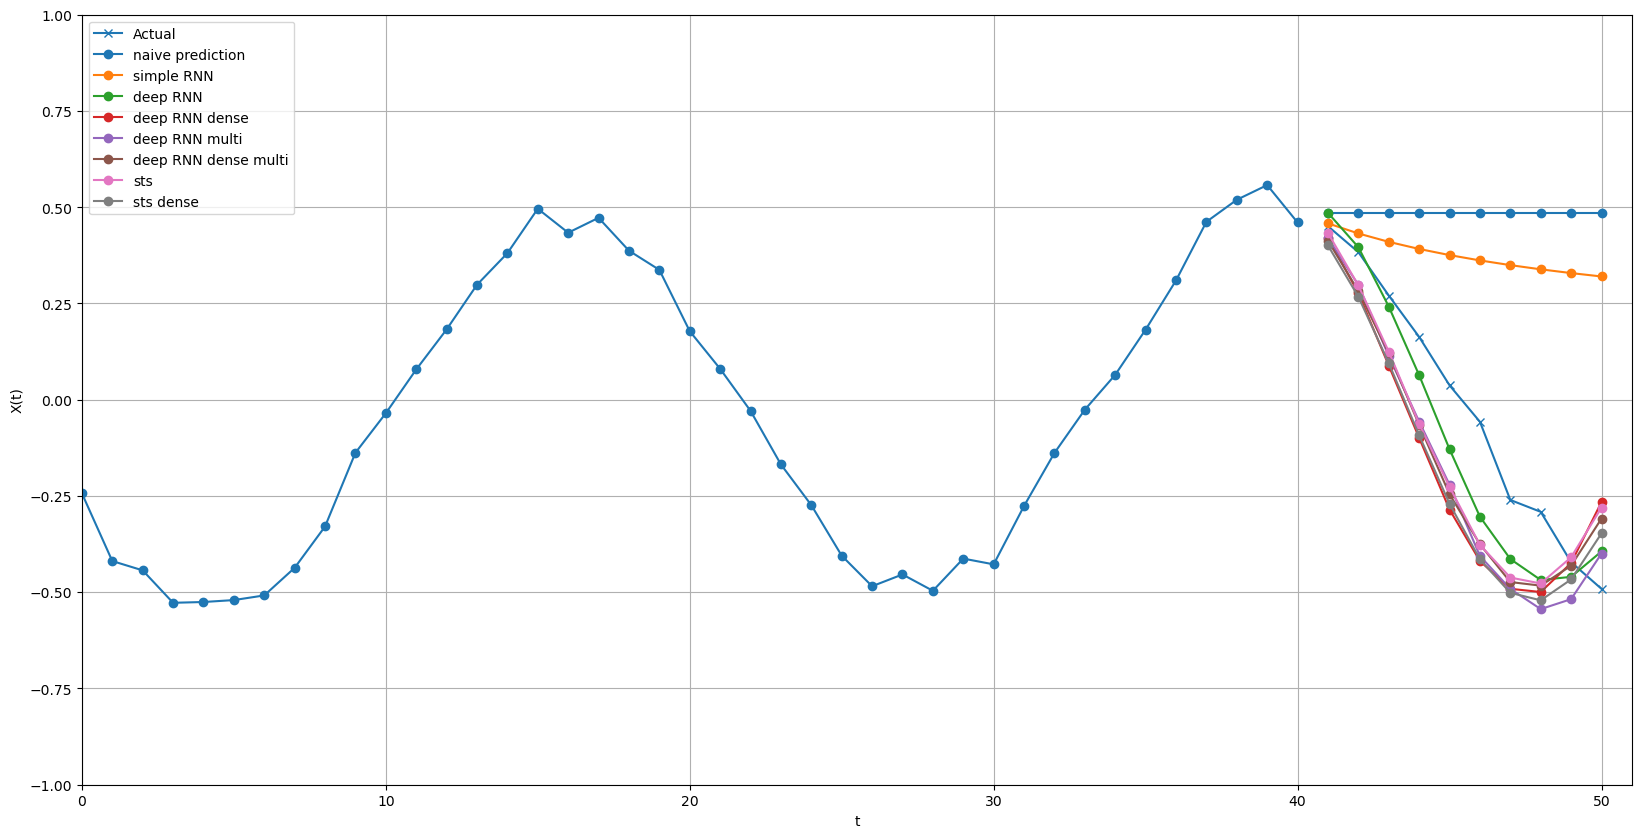

In [67]:
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

matplotlib.rc("text", usetex=False)

# n_steps_total = n_steps + n_steps_ahead
n_steps_known = len(X_test_multi[0])
n_steps_pred = len(y_test_multi[0])
n_steps_total = n_steps_known + n_steps_pred
t_pred = range(n_steps_known, n_steps_known + n_steps_pred)
y_true = y_test_multi[0]

fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(X_test_multi[0, :, 0], c="tab:blue", marker="o")
ax.plot(t_pred, y_true, c="tab:blue", marker="x", label="Actual")
for (model_name, y_pred), color in zip(
    y_pred_models.items(), mcolors.TABLEAU_COLORS.keys()
):
    ax.plot(t_pred, y_pred, c=color, marker="o", label=model_name)
ax.grid()
ax.set_xlim([0, n_steps_total])
ax.set_ylim([-1, 1])
ax.set_xlabel("t")
ax.set_ylabel("X(t)")
ax.legend();

In [70]:
import pandas as pd
from sklearn.metrics import mean_squared_error

mses = pd.Series(
    np.sqrt(
        [
            mean_squared_error(y_true, y_pred)
            for model_name, y_pred in y_pred_models.items()
        ]
    ),
    index=y_pred_models.keys(),
)
mses

naive prediction        0.599264
simple RNN              0.485332
deep RNN                0.128915
deep RNN dense          0.222804
deep RNN multi          0.201082
deep RNN dense multi    0.195728
sts                     0.192840
sts dense               0.216381
dtype: float64